<a href="https://colab.research.google.com/github/Estabraq-makiyah/AwesomeResources/blob/master/Multi_Agent.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install tqdm -q


In [ ]:
import sys
sys.path.insert(0, '/content')

MA-DTSR Simulation — Step 1: Mobility Model
Config: N=100, grid=1000m, range=100m, T=100 steps



Running mobility simulation: 100%|██████████| 99/99 [00:02<00:00, 46.43step/s]


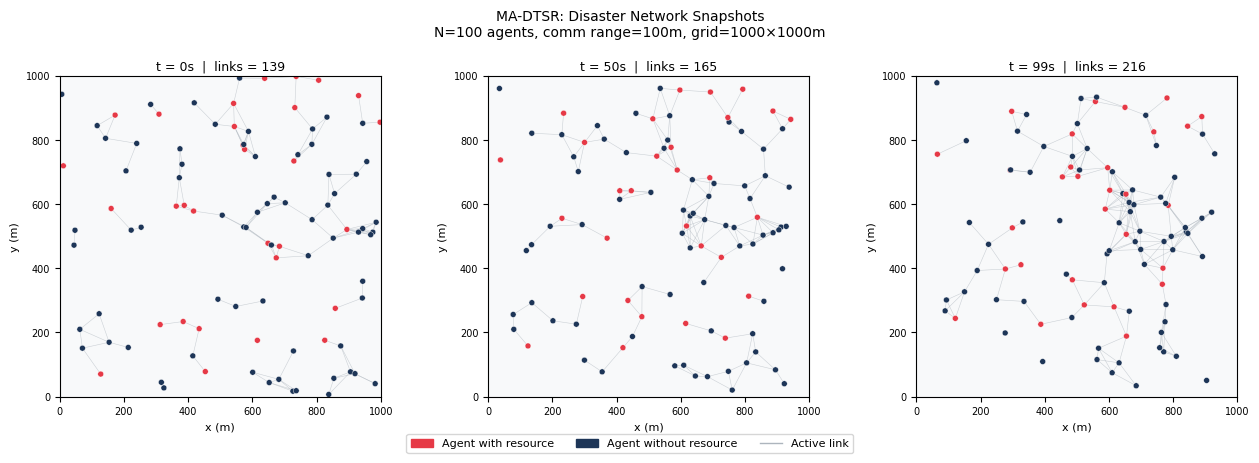

Figure 1 saved: step1_network_snapshots.png


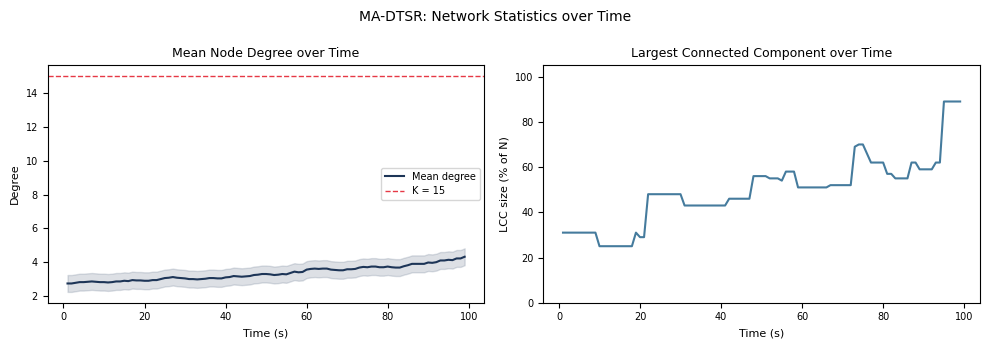

Figure 2 saved: step1_network_stats.png

  MA-DTSR Step 1 — Sanity Check Results
  N agents          : 100
  Grid size         : 1000 x 1000 m
  Comm range        : 100 m
  Time steps run    : 99
  Resource agents   : 30

  --- Degree Statistics ---
  Mean avg degree   : 3.34  (target: 2–8)
  Max avg degree    : 4.32
  Min avg degree    : 2.74

  --- Connectivity ---
  Mean LCC fraction : 49.5%  (target: 60–90%)
  Mean isolated     : 4.5 agents

  --- Links ---
  Mean link count   : 167.2
  Max link count    : 216
  All checks passed. Network parameters look good.


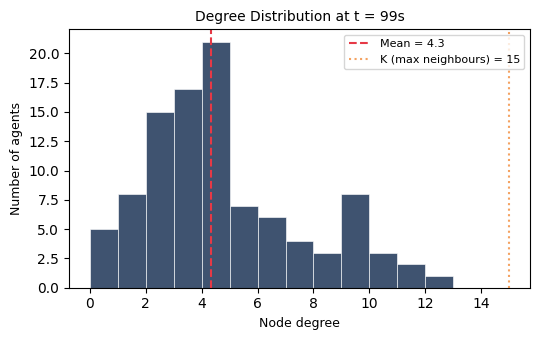

Figure 3 saved: step1_degree_distribution.png

Step 1 complete. Three figures generated.
Next step: run Step 2 (resource descriptors and contact database).


In [ ]:
import MA_DTSR_Step1_Mobility as step1
net = step1.main()

MA-DTSR Simulation — Step 2: Resource Descriptors
Network: N=100 agents, t=99s

Populating 8-dimensional resource descriptors...
Descriptors populated for 30 resource agents.
Rebuilding contact database with populated descriptors...
Contact database rebuilt: 119 entries across 100 agents.

  MA-DTSR Step 2 — Descriptor Sanity Check Results
  Resource agents with descriptors : 30
  Admissibility threshold epsilon  : 1.0

  [PASS] All descriptor values in [0, 1]
  [PASS] Dim 3 (location zone) matches agent position
  [PASS] Dim 7 (energy) matches agent.energy
  [PASS] Self-distance (L1) = 0.000000 (should be 0)
  [PASS] D_alpha(age=0) == D_L1 = 2.1979
  [PASS] D_alpha monotonically increases: 2.198 <= 3.624 <= 26.775
  [PASS] Masked distance <= full distance (0.161 <= 2.198)
  [INFO] Admissibility rate at epsilon=1.0: 14.8% of queries find a match
  [PASS] Admissibility rate is within realistic range.
  [PASS] Contact database has 119 entries

  --- Category Distribution ---
  transport 

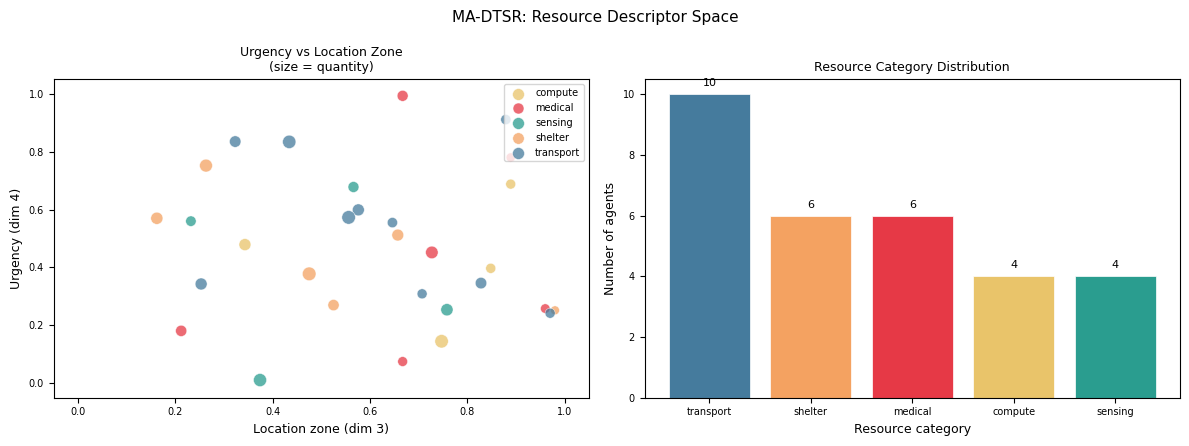

Figure 4 saved: step2_descriptor_space.png


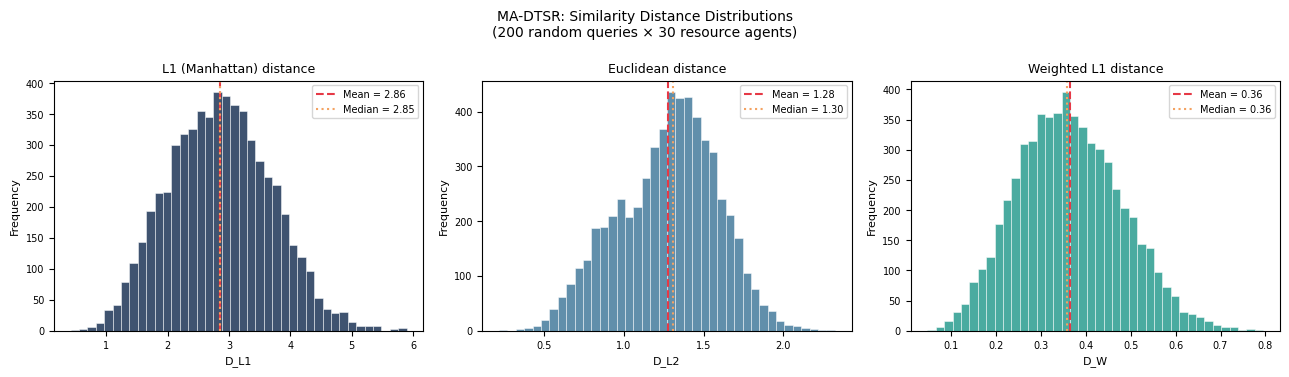

Figure 5 saved: step2_similarity_distributions.png


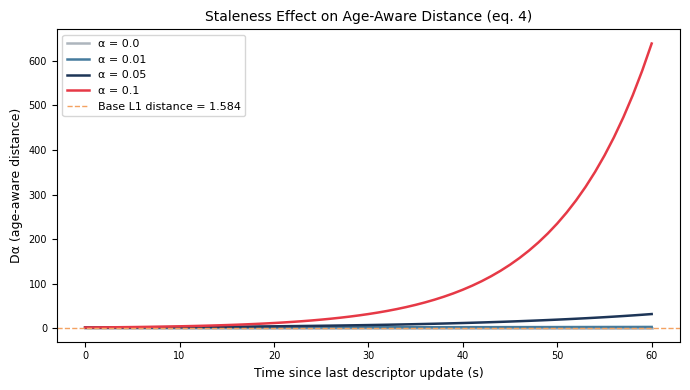

Figure 6 saved: step2_staleness_effect.png


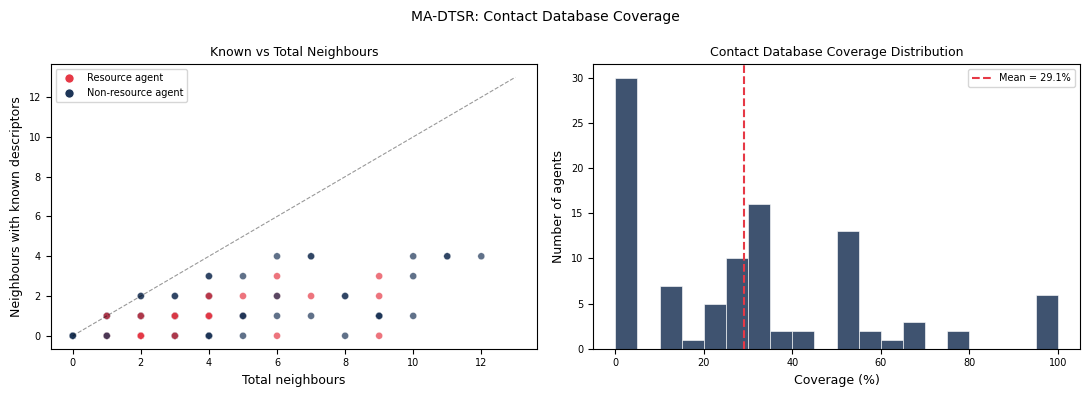

Figure 7 saved: step2_contact_coverage.png

Step 2 complete. Four figures generated (Figures 4–7).
The 'net' object is updated in place with full descriptors.
Keep this session open — Step 3 builds directly on top.


In [ ]:
import MA_DTSR_Step2_Descriptors as step2
meta = step2.main_step2(net)

MA-DTSR Simulation — Step 3: Baseline Routing Protocols
Network  : N=100 agents, t=99s
Episodes : 200 per (protocol, TTL)
TTL range: [10, 20, 30, 40]
Epsilon  : 1.0  |  Alpha: 0.01  |  Beta: 2.0



Running protocols: 100%|██████████| 2400/2400 [00:01<00:00, 2214.55ep/s]



--- Results Summary ---
        protocol  ttl  success_rate  mean_hops  mean_messages  mean_mae  mean_utility
        Epidemic   10         0.095      9.605         54.910     0.816         0.033
        Epidemic   20         0.105     18.785         76.120     0.766         0.025
        Epidemic   30         0.075     28.265         73.840     0.848         0.021
        Epidemic   40         0.120     36.080         73.940     0.821         0.034
Heuristic-MADTSR   10         0.040      6.860          6.900     0.821         0.031
Heuristic-MADTSR   20         0.055     10.325         10.380     0.878         0.036
Heuristic-MADTSR   30         0.060     11.175         11.235     0.869         0.038
Heuristic-MADTSR   40         0.030     11.665         11.695     0.888         0.017
      RandomWalk   10         0.005      6.770          6.775     0.913         0.004
      RandomWalk   20         0.025      9.765          9.790     0.887         0.016
      RandomWalk   30        

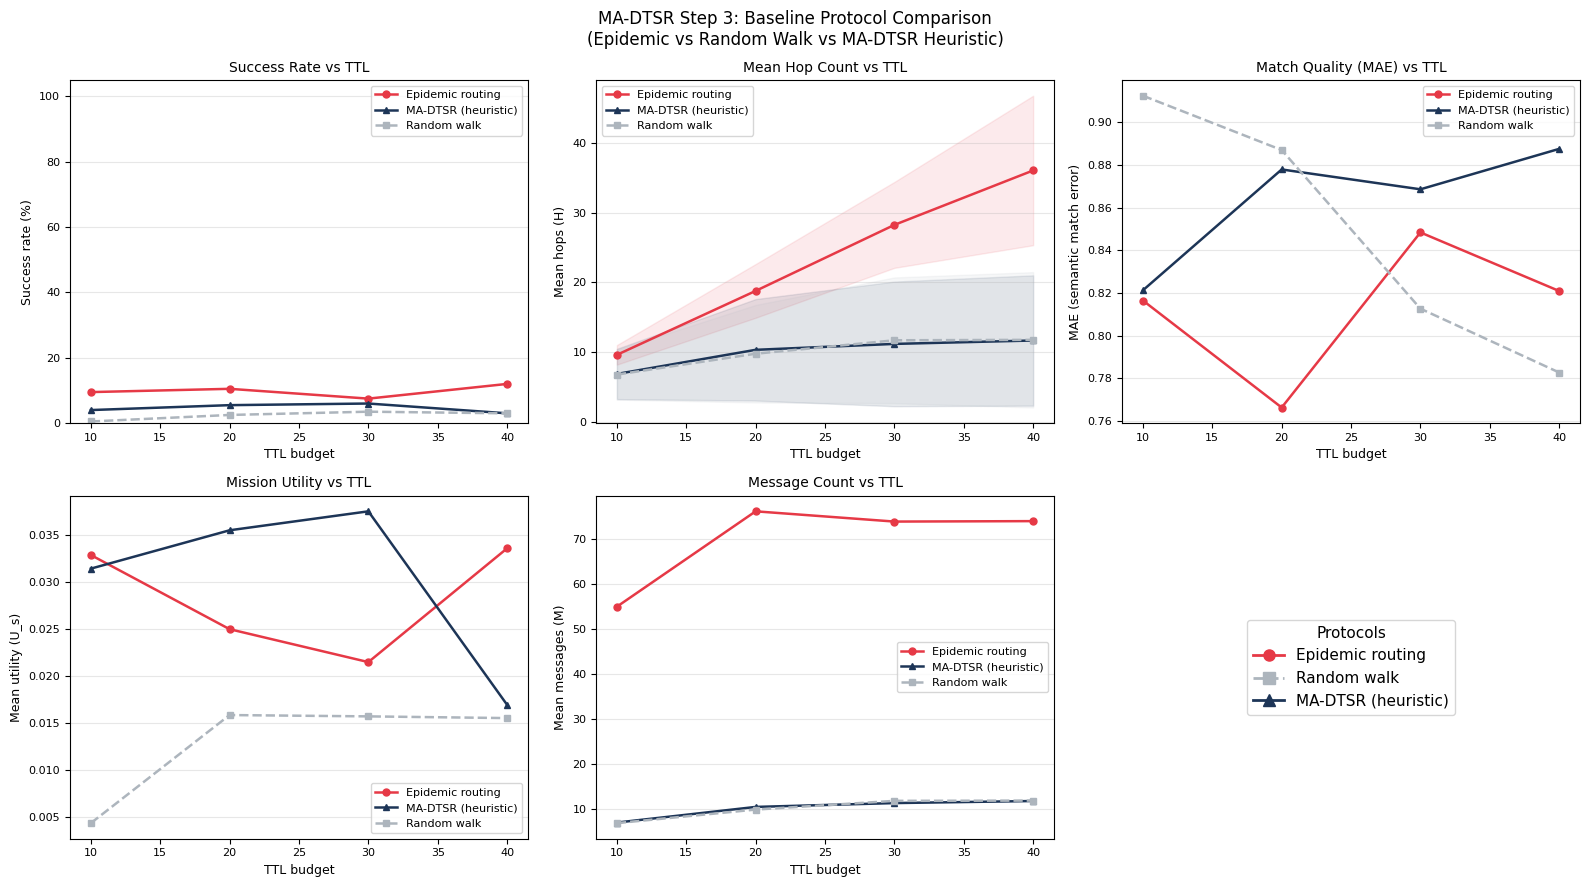

Figure saved: step3_comparison.png
Results saved: step3_raw_results.csv, step3_summary.csv


In [ ]:
import MA_DTSR_Step3_Baselines as step3
df, summary, routers = step3.main_step3(net, step2)

MA-DTSR Simulation — Step 4: RL-Augmented Routing
Network    : N=100 agents, t=99s
Training   : 500 episodes per TTL value
Evaluation : 200 episodes per TTL value
TTL range  : [10, 20, 30, 40]
Params     : epsilon=1.0, alpha=0.01, beta=2.0, lr=0.05

Phase 1: Training on TTL=30...
  Training RL router: 500 episodes, TTL=30, rho_start=0.80


  Training complete. Final rho=0.0653, Total updates=5469

Phase 2: Evaluating RL router (greedy policy)...

Phase 3: Running baseline protocols for comparison...


Running protocols: 100%|██████████| 2400/2400 [00:01<00:00, 1323.92ep/s]



--- Full Results Summary ---
        protocol  ttl  success_rate  mean_hops  mean_messages  mean_utility
        Epidemic   10         0.095      9.605         54.910         0.033
        Epidemic   20         0.105     18.785         76.120         0.025
        Epidemic   30         0.075     28.265         73.840         0.021
        Epidemic   40         0.120     36.080         73.940         0.034
Heuristic-MADTSR   10         0.040      6.840          6.880         0.031
Heuristic-MADTSR   20         0.055     10.380         10.435         0.036
Heuristic-MADTSR   30         0.065     11.390         11.455         0.048
Heuristic-MADTSR   40         0.035     11.990         12.025         0.022
       RL-MADTSR   10         0.025      7.365          7.390         0.018
       RL-MADTSR   20         0.030     10.380         10.410         0.022
       RL-MADTSR   30         0.035      9.040          9.075         0.027
       RL-MADTSR   40         0.015     10.725         10.

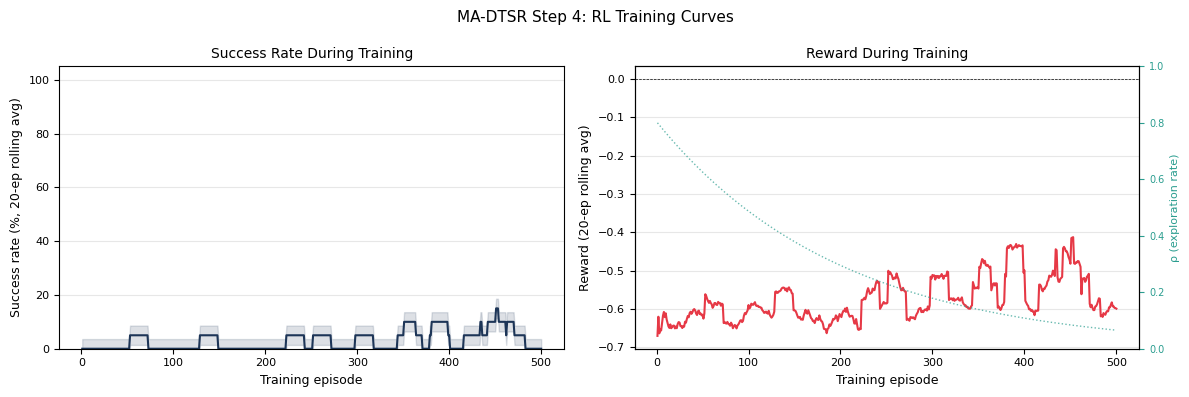

Figure 12 saved: step4_learning_curves.png


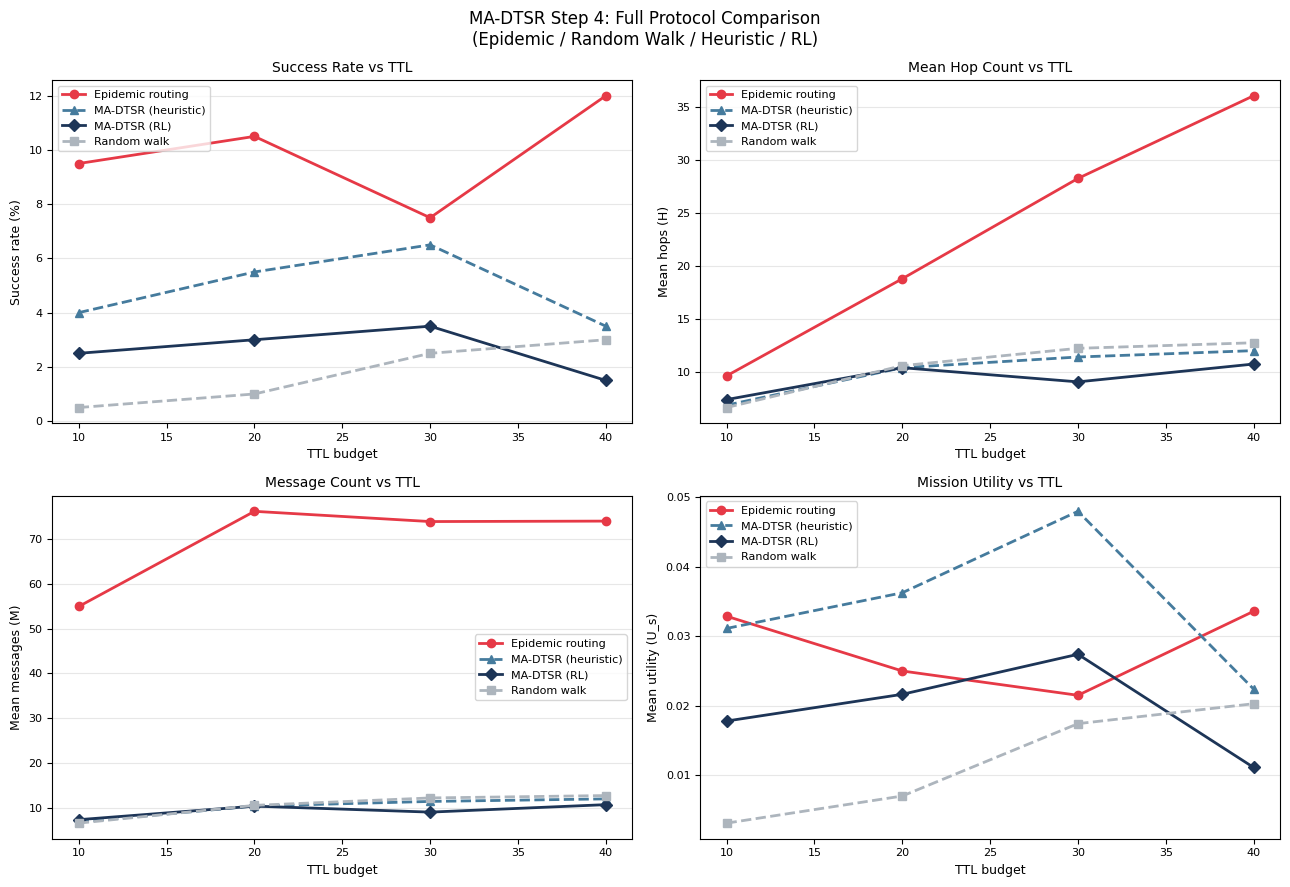

Figure 13 saved: step4_full_comparison.png


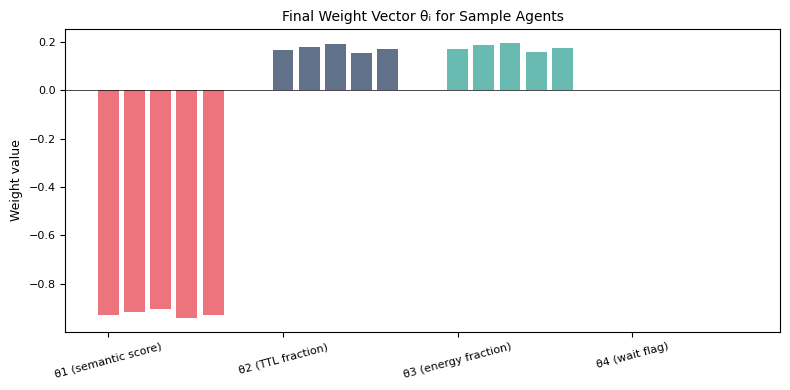

Figure 14 saved: step4_weight_evolution.png

Results saved:
  step4_raw_results.csv
  step4_summary.csv
  step4_training_log.csv


In [ ]:
import MA_DTSR_Step4_RL as step4
df4, summary4, rl_router = step4.main_step4(net, step2, step3)